# Assignment 2
Interpretability and Bias in ML, University of Göttingen, March 2026

## Part A: Saliency

**Credits**: *Adapted for the InBiML lecture by Jonas Mayer Martins (April 2025). Assignment created by Jaap Jumelet, with additional help from Tom Kersten and Jelle Zuidema. Part of the UvA AI MSc course Interpretability & Explainability in AI, June 2022. Updated to fit within one werkcollege by Maria Heuss (June 2024).*

*The original notebook for Interpretability & Explainability in AI, MSc A.I., University of Amsterdam, June 2023 is available here: https://github.com/clclab/IEinAI/tree/main/book/week1.*

### When to start working on this part
Even though there will be a tutorial class where you can work on completing this notebook and the report we recommend having a look at the notebook and giving it a try before your exercise class. That way you can make sure that you are getting the most out of the tutorial class by asking some focused questions.

### Introduction
In this notebook you will gain a better understanding of Feature Attribution methods. Feature Attribution methods explain the prediction of a model as a sum of contributions from the input features. For example, if we were to explain the output of a language model (that assigns a probability to the next token) on the input "*The athletes above Barbara ...*", the output of "*walk*" could be explained as the following sum of contributions:

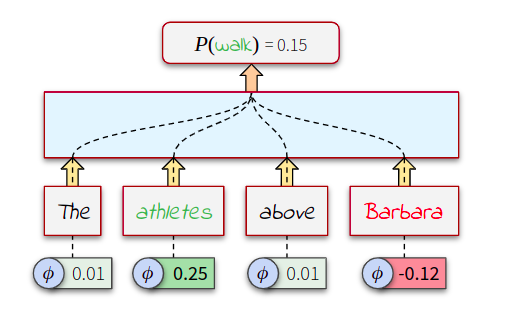

A multitude of attribution methods has been proposed over the passed few years. You may have heard of some of them, like LIME, SHAP, Integrated Gradients, or GradCAM. Each of these methods has its own strengths and weaknesses, but it has become increasingly harder to make sense of which method is truly the most **faithful** to the actual behaviour of the underlying model. This is a notoriously hard problem, because we don't have access to the "*gold explanation*" of model behaviour: It is, after all, precisely this gold explanation that we are trying to obtain via feature attribution methods.

## Task
In this task we will focus on a small subset of attribution methods, and compare these. We will look into methods that aim to evaluate and quantify the faithfulness of an attribution method. You will use these methods to conduct a small-scale qualitative analysis on a **sentiment classification** model. Ideally attribution methods will give us a better, more qualitative insight into its behavior.

## Models and Data

For your experiments, you will make use of the RoBERTa model ([Liu et al. 2019 ](https://arxiv.org/abs/1907.11692)). RoBERTa, as you may recall, is an extension of BERT for which the pretraining procedure has been changed. Importantly, RoBERTa has been trained on more data, with longer sequences. However, it removed the next sentence prediction objective.

We will evaluate our model using the Stanford Sentiment Treebank (or [SST2](https://arxiv.org/abs/1804.07461)) dataset. The dataset consists out of 11,855 movie reviews, each annotated with sentiment. This kind of data is ideal for attribution extraction, as sentiment often contains very clear words which mark the sentiment for that sentence.

**Note:** Inference with some models may take long on a CPU. You may want to run the notebook locally on your machine or use a cloud-based alternative (Google Colab, ...). Don't forget to enable the GPU runtime (Runtime -> Change runtime type) in Jupyter / Colab / Keggle. Alternatively, to use a GPU with the GWDG JupyterHub (https://jupyter.hpc.gwdg.de/hub/spawn), please contact the tutor to request access.

**Note:** If you are running this locally (not on Google Colab or a pre-configured environment), you might need to install these libraries. Uncomment and run the `!pip install ...` line in the code cell below if needed.

In [106]:
#!pip install transformers datasets captum

import transformers
import torch
import os
import numpy as np
import pandas as pd
from typing import *
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel


os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_model(path):
    tokenizer = AutoTokenizer.from_pretrained(path)
    model = AutoModelForSequenceClassification.from_pretrained(path)
    model.eval()
    model.to(DEVICE)

    return model, tokenizer


# We use a fine-tuned roberta model in our experiments
model, tokenizer = load_model("textattack/roberta-base-SST-2")

Some weights of the model checkpoint at textattack/roberta-base-SST-2 were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


For the sentiment classification task we will make use of Huggingface's `datasets` library, which makes it very easy to load in SST2 and do post-processing on it.

In [107]:
from datasets import load_dataset


# We can directly load in the SST2 dataset
dataset = load_dataset("gpt3mix/sst2")


# We still need to encode the raw sentences based on the tokenizer we're using
def encode(batch):
    encoded = tokenizer(
        batch["text"],
        padding="longest",
        truncation=True,
        max_length=512,
        return_tensors="pt",
    ).to(DEVICE)

    # Invert labels (0 <> 1), because it's the other way around somehow for roberta
    batch['label'] = (~torch.tensor(batch['label']).bool()).long()
    batch['original_text'] = batch['text'] # my addition for easier readability
    batch['text'] = [
        tokenizer.tokenize(sen, add_special_tokens=True)
        for sen in batch['text']
    ]

    return {**encoded, **batch}


def detokenize(tokens, single_string=True):
    """
    Convert tokenized text back to a human-readable format. We will use this
    function to make our examples easier to read.

    Args:
    tokens (list of str): The tokenized text.

    Returns:
    str: The detokenized, human-readable text.

    """
    if not single_string:
      return [token.replace('Ġ', ' ') if token not in ['<s>', '</s>'] else token for token in tokens ]
    return ''.join(token.replace('Ġ', ' ') for token in tokens if token not in ['<s>', '</s>']).strip()



dataset.set_transform(encode)

<font color='green'><b>ToDo 1</b></font>

Inspect the data you have been given. Make sure you understand what the data looks like, and what the labels mean. Iterate over your data, and see what happens if you try to access a single item in the corpus, or multiple at once.

In [3]:
num_examples = 2
for i in range(num_examples):
    print(f"example {i}")
    for attr, value in dataset['train'][i].items():
        print(f"{attr:<15}", value)
    print("---------------")

example 0
input_ids       tensor([    0,   133,  2751,    16, 19083,     7,    28,     5,   733,   620,
         9348,   128,    29,    92, 45518, 38650, 12801,     8,    14,    37,
          128,    29,   164,     7,   146,    10, 17158,   190,  2388,    87,
        11816, 28797,  2156,  5363,    12, 11428,  5247,  3415,  8234,  1794,
           50,  5031,  1608,  9487,   479,     2])
attention_mask  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
text            ['<s>', 'The', 'ĠRock', 'Ġis', 'Ġdestined', 'Ġto', 'Ġbe', 'Ġthe', 'Ġ21', 'st', 'ĠCentury', "Ġ'", 's', 'Ġnew', 'Ġ``', 'ĠConan', "Ġ''", 'Ġand', 'Ġthat', 'Ġhe', "Ġ'", 's', 'Ġgoing', 'Ġto', 'Ġmake', 'Ġa', 'Ġsplash', 'Ġeven', 'Ġgreater', 'Ġthan', 'ĠArnold', 'ĠSchwarzenegger', 'Ġ,', 'ĠJean', '-', 'Cl', 'aud', 'ĠVan', 'ĠDam', 'me', 'Ġor', 'ĠSteven', 'ĠSe', 'gal', 'Ġ.', '</s>']
label           tensor(1)
original_text   The Rock 

Now that you have inspected the data, let us try to use it alongside the loaded model.

<font color='green'><b>ToDo 2</b></font>

*   Produce a prediction using the model for the first sentence in the dataset in the test set. What sentiment is being predicted? Does this agree with the actual sentiment label?
*   List the first 5 sentences from the test set for which the model produces **incorrect** predictions (in the test set).

<font color='red'><b>ToSubmit 1</b></font>
The list of 5 sentences you have found on which the model makes an incorrect prediction. Add a brief caption to the listing in which you state some patterns that you observe (max. 50 words).

In [108]:
# Function to make predictions
def predict(data_point):
    input_ids = data_point['input_ids'].unsqueeze(0).to(DEVICE)
    attention_mask = data_point['attention_mask'].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

    logits = outputs.logits
    probabilities = torch.softmax(logits, dim=-1)
    predicted_class = torch.argmax(probabilities, dim=-1).item()
    return predicted_class, probabilities

In [279]:
# Your code here (list 5 sentences with incorrect predictions)
# NOTE: for examples 53 and 119 I don't agree with the labels of the dataset, so I skipped them
examples_to_ignore = [53, 119]
examples_left = 5
i = 0

while examples_left > 0:
    if i in examples_to_ignore:
        i += 1
        
    example = dataset['test'][i]
    prediction = predict(example)
    if example["label"] != prediction[0]:
        print(f"example {i} -- label: {example["label"]} -- predicted label: {prediction[0]}")
        print(example["original_text"])
        print(example["text"])
        print()
        examples_left -= 1
    i += 1

print("\n\n'unfortunately', 'best work', 'deserves [...] prizes', 'attempts' are generally used in sentences with different sentiment from what these sentences have. example 26 and 134 talk good/bad about one thing, but the general sentiment is the other.")

example 3 -- label: 1 -- predicted label: 0
Perhaps no picture ever made has more literally showed that the road to hell is paved with good intentions .
['<s>', 'Perhaps', 'Ġno', 'Ġpicture', 'Ġever', 'Ġmade', 'Ġhas', 'Ġmore', 'Ġliterally', 'Ġshowed', 'Ġthat', 'Ġthe', 'Ġroad', 'Ġto', 'Ġhell', 'Ġis', 'Ġpaved', 'Ġwith', 'Ġgood', 'Ġintentions', 'Ġ.', '</s>']

example 26 -- label: 1 -- predicted label: 0
If there 's a way to effectively teach kids about the dangers of drugs , I think it 's in projects like the -LRB- unfortunately R-rated -RRB- Paid .
['<s>', 'If', 'Ġthere', "Ġ'", 's', 'Ġa', 'Ġway', 'Ġto', 'Ġeffectively', 'Ġteach', 'Ġkids', 'Ġabout', 'Ġthe', 'Ġdangers', 'Ġof', 'Ġdrugs', 'Ġ,', 'ĠI', 'Ġthink', 'Ġit', "Ġ'", 's', 'Ġin', 'Ġprojects', 'Ġlike', 'Ġthe', 'Ġ-', 'L', 'RB', '-', 'Ġunfortunately', 'ĠR', '-', 'rated', 'Ġ-', 'RR', 'B', '-', 'ĠPaid', 'Ġ.', '</s>']

example 90 -- label: 1 -- predicted label: 0
4 friends , 2 couples , 2000 miles , and all the Pabst Blue Ribbon beer they can d

## Attribution Methods

For this task, you will look at several existing attribution methods, see how they work and compare and contrast their similarities and differences. For your experiments, you will consider the following attribution methods:

* Feature Ablation
* Shapley Values
* Integrated Gradients
* KernelShap

To make sure these four methods are compatible with subsequent evaluation procedures, we will let each instantiation inherit from an abstract `FeatureAttributor` class. Note that this class also contains a method to retrieve the model logits, which may be of use in your implementation of the attribution methods. We will generate explanations based on the change of logits, rather than the change in class probability.

You can use the `visualize_attribution` method to visualize the attributions for a particular method. Note that this visualizes positive (green) or negative (red) contributions to whatever the model predicts for a given sample; the colors do *not* directly refer to positive or negative sentiment!

In [109]:
from abc import abstractmethod

from captum.attr import visualization
from IPython.display import display, HTML


class FeatureAttributor:
    def __init__(self, model):
        self.model = model

    @abstractmethod
    def attribute(
        self,
        input_ids: torch.Tensor,
        baseline_ids: torch.Tensor,
        target: int,
        **kwargs
    ) -> torch.Tensor:
        """
        Computes the attributions for a single input.

        Parameters
        ----------
        input_ids : torch.Tensor
            shape: (batch_size, sen_len)
        baseline_ids : torch.Tensor
            shape: (batch_size, sen_len)
        target : int
            Output class that is being explained

        Returns
        -------
        attributions : torch.Tensor
            shape: (sen_len,)
        """
        pass

    def logits(self, input_ids, target=None):
        squeeze_output = input_ids.ndim == 1
        if squeeze_output:
            input_ids = input_ids.unsqueeze(0)

        with torch.no_grad():
            if target is None:
              logits = self.model(input_ids).logits
            else:
              logits = self.model(input_ids).logits[:, target]

        if squeeze_output:
            logits = logits.squeeze()

        return logits


def visualize_attribution(sen: List[str], attributions: torch.Tensor, normalize: bool = True, human_readable = True):
    attributions = attributions.squeeze()

    if normalize:
        attributions /= torch.max(attributions.abs())

    if human_readable:
        sen = detokenize(sen, single_string=False)

    raw_html = visualization.format_word_importances(
        sen, attributions
    )
    html = HTML(raw_html)
    display(html)

### Feature Ablation

Feature Ablation ([Li, Monroe and Jurafsky, 2016](https://arxiv.org/abs/1612.08220)) is a simple attribution method. We replace individiual tokens in the sentence with some baseline token, and measure the difference in output between the original sentence and the modified one. We then assign the resulting difference to the replaced token. This procedure is summarised in the following formula, where $a_{i}$ is the attribution score for the token at position $i$, $\mathcal{M}$ is the model and $\mathcal{F}_{i}$ is the replacement method at position $i$.

$$a_{i}(x) = \mathcal{M}(x) - \mathcal{M}(\mathcal{F}_i(x))$$

<font color='blue'><b>ToThink 1</b></font> Consider how we may model the exclusion of one or multiple tokens from our input. Do you completely remove the feature? Replace it with a default token? Or sample it from a distribution? What impact do these choices have on your explanations?

<font color='turquoise'><b>Thoughts 1</b></font> Sampling it from a distribution would introduce randomness, which would require us to exclude the same token multiple times to get a more consistent picture of what effect this has.

<font color='green'><b>ToDo 3</b></font>
Implement the ablation attribution method below. You can test your method on the example sentence that has been provided.

In [110]:
class AblationAttributor(FeatureAttributor):
    def attribute(
        self,
        input_ids: torch.Tensor,
        baseline_ids: torch.Tensor,
        target: int,
    ) -> torch.Tensor:

        seq_len = input_ids.size(0)
        attributions = torch.zeros(seq_len, device=input_ids.device)

        # Get model output for original input
        orig_logits = self.logits(input_ids.unsqueeze(0))    # shape: [1, num_classes]
        orig_output = torch.softmax(orig_logits, dim=-1)[0, target]

        # === Your code for computing feature ablation ===
        # For each token position, ablate (replace) the token and re-compute output; then calculate the attributions and return them

        for i in range(1, seq_len - 1):
            modified_input_ids = input_ids.clone()
            modified_input_ids[i] = baseline_ids[i]
            modified_logits = self.logits(modified_input_ids)
            attributions[i] = orig_logits[:,target] - modified_logits[target]

        return attributions


sen = "I wish I liked it more, although I did not dislike it"
item = {
    "input_ids": tokenizer(sen, return_tensors='pt').to(DEVICE)['input_ids'].squeeze(),
    "text": tokenizer.tokenize(sen, add_special_tokens=True),
    "label": torch.tensor(1),
}
input_ids = item['input_ids']
sen_len = len(item['text'])

baseline_id = tokenizer.unk_token_id  # Set the baseline to the <unk> toke
baseline_ids = torch.tensor([baseline_id] * sen_len, device=DEVICE)
label = item['label'].item()

ablation_attributor = AblationAttributor(model)
ablation_attributions = ablation_attributor.attribute(input_ids, baseline_ids, label)

for w, phi in zip(detokenize(item['text'], single_string=False), ablation_attributions):
    print(f"{w:<15} {phi.item():.3f}")

visualize_attribution(item['text'], ablation_attributions)
print(ablation_attributor.logits(input_ids))


<s>             0.000
I               -0.639
 wish           -2.191
 I              -0.820
 liked          -0.512
 it             -0.150
 more           -0.155
,               -0.139
 although       -1.002
 I              0.082
 did            -0.264
 not            2.194
 dislike        1.397
 it             0.665
</s>            0.000


tensor([ 0.1251, -0.1425])


### Shapley Values

Another approach to assigning attribution scores comes from game theory. Shapley values ([Shapley, 1951](https://www.rand.org/pubs/research_memoranda/RM0670.html)) provide a framework for the assignment of contributions to players in a team. More specifically, we can estimate the contributions of a player by comparing the results of all coalitions including our player to those same coalitions without our player. These differences indicate the contributions of our player towards the game, and can be considered their attribution. The mathematical formulation for this procedure is as follows:

\begin{align*}
\phi_i &=
\underbrace{
      \sum_{S \subseteq \mathbf{x} \setminus \{i\}}
      }_{\text{coalitions without $i$}}
    \underbrace{
      p(S) \big(
          v(S \cup \{i\}) - v(S)
      \big)
      }_{\text{marginal contribution of $i$ to coalition}}
\\\\
p(S)
&=
\underbrace{
\frac{|S|!\, (|\mathbf{x}| - 1 - |S|)!}{|\mathbf{x}|!}}_{\text{relative number of coalitions of size $|S|$}}
\end{align*}

- $\phi_i$: Shapley value (attribution) for feature $i$
- $S$: Subset of input features not containing $i$
- $\mathbf{x}$: Set of all input features
- $p(S)$: Weight for coalition $S$
- $v(S)$: Model output for features in $S$
- $v(S \cup \{i\})$: Model output for $S$ plus $i$
- $|S|$: Number of features in $S$
- $|\mathbf{x}|$: Total number of input features

We can translate this concept to NLP by considering the team to be the input to the model. As such the players in our imaginary game have become the tokens in the input. We can evaluate the performance by looking at all possible coalitions (i.e. subsets) of our input with respect to a single token, either including or excluding it.

<font color='blue'><b>ToThink 2</b></font> How does the computation of a Shapley value scale, in terms of the number of input features?

<font color='turquoise'><b>Thoughts 2</b></font> $O(2^N)$

<font color='green'><b>ToDo 4</b></font>
Fill in the missing part in `ShapleyAttributor.attribute` below. The model outputs have been pre-computed (`coalition_logits`), so all that is left to do is to finish the Shapley computation steps as outlined in the mathematical formulation above.

In [114]:
from itertools import chain, combinations
from math import factorial
from tqdm import notebook


def powerset(iterable):
    s = list(iterable)
    return chain.from_iterable(combinations(s, r) for r in range(len(s) + 1))


def coalitions_without_i(sen_len, i):
    features_not_i = [j for j in range(sen_len) if j != i]
    for coalition in powerset(features_not_i):
        yield coalition


class ShapleyAttributor(FeatureAttributor):
    def attribute(
        self,
        input_ids: torch.Tensor,
        baseline_ids: torch.Tensor,
        target: int,
    ) -> torch.Tensor:
        sen_len = input_ids.shape[-1]

        coalition_logits, coalition_to_index = self.compute_coalition_logits(
            input_ids, baseline_ids, target
        )

        shapley_values = torch.zeros(sen_len)

        p_S = torch.zeros(sen_len)
        for size in range(sen_len):
            p_S[size] = (factorial(size) * factorial(sen_len - 1 - size)) / factorial(sen_len)

        for i in range(sen_len):
            for S in coalitions_without_i(sen_len, i):
                S_i = tuple(sorted(S + (i,)))
                index_S = coalition_to_index[S]
                index_S_i = coalition_to_index[S_i]

                # Your code for computing the Shapley value
                # Note you can use the index_S and index_S_i values to index the coalition_logits defined above

                # NOTE I precompute and save the values for p(S) above
                shapley_values[i] += p_S[len(S)] * (coalition_logits[index_S_i] - coalition_logits[index_S])

        return shapley_values

    def compute_coalition_logits(self, input_ids, baseline_ids, target):
        """
        Computes the model output for all possible coalitions, in batches.

        Returns
        -------
        coalition_logits : torch.Tensor
            shape: (2**sen_len,)
            The output logit for each coalition
        coalition_to_index : Dict[Tuple[int], int]
            Dictionary mapping a coalition tuple to its index in the
            coalition_logits tensor.
        """
        sen_len = input_ids.shape[-1]
        num_coalitions = 2**sen_len

        coalitions = torch.zeros(num_coalitions, sen_len, dtype=torch.long).to(DEVICE)
        coalitions += baseline_ids  # set baseline as default

        coalition_to_index = {}

        for idx, coalition in enumerate(powerset(range(sen_len))):
            coalition_to_index[coalition] = idx
            if len(coalition) > 0:
                coalition = list(coalition)
                coalitions[idx, coalition] = input_ids[coalition]

        coalition_logits = torch.zeros(num_coalitions)
        batch_size = 1024
        batch_iterator = torch.split(coalitions, batch_size)
        for batch_idx, batch in notebook.tqdm(
            enumerate(batch_iterator), total=len(batch_iterator)
        ):
            with torch.no_grad():
                batch_logits = self.logits(batch, label)
            coalition_logits[
                batch_idx * batch_size : (batch_idx + 1) * batch_size
            ] = batch_logits

        return coalition_logits, coalition_to_index


shapley_attributor = ShapleyAttributor(model)
shapley_attributions = shapley_attributor.attribute(input_ids, baseline_id, label)

visualize_attribution(item["text"], shapley_attributions)


  0%|          | 0/32 [00:00<?, ?it/s]

### KernelSHAP

Directly computing Shapley values is an expensive process, as it scales exponentially with the size of the input. Because of this, computing Shapley values for larger inputs becomes infeasible, especially over larger datasets. As such, approximations are needed to compute these values.

KernelSHAP ([Lundberg and Lee, 2017](https://arxiv.org/abs/1705.07874)) is one such approximation. It seeks to reduce the complexity to a managable scale by using a different approach called LIME ([Ribeiro, Singh, and Guestrin, 2016](https://arxiv.org/abs/1602.04938)). LIME produces a linear approximation of a model, and we can inspect this surrogate model. LIME trains a linear model on a simplified input, noting the presence or absence of individual training features, which produces a model which is able to mimic the original model. However, for this process a loss function, weight kernel and a regularization term are needed. Lunderberg and Lee (2017) show that by carefully choosing these parameters, the regression coefficients of the model resemble the corresponding Shapley values.

<font color='green'><b>ToDo 5</b></font>
Here, the `ShapAttributor.attribute` is already complete, making use of the `captum` implementation of KernelSHAP (check out the API [here](https://captum.ai/api/kernel_shap.html)). Experiment with the number of coalitions that are being sampled (n_samples) and make sure the estimation is fairly stable.


In [111]:
from captum.attr import KernelShap

class ShapAttributor(FeatureAttributor):
    def attribute(
        self,
        input_ids: torch.Tensor,
        baseline_ids: torch.Tensor,
        target: int,
        n_samples: int = 400 # how many random feature coalitions to sample (higher: more accurate)
        # until 400 there were big changes whenever I increased the number. From 400 up it seemed to stabilise, so I chose that
    ) -> torch.Tensor:
        input_ids = input_ids.unsqueeze(0)       # [1, seq_len]
        baseline_ids = baseline_ids.unsqueeze(0) # [1, seq_len]
        ks = KernelShap(self.logits)

        # KernelShap returns a tensor of shape [1, seq_len]
        attributions = ks.attribute(
            input_ids,
            baselines=baseline_ids,
            target=target,
            n_samples=n_samples,
        )
        return attributions.squeeze(0)  # [seq_len]

shap_attributor = ShapAttributor(model)
shap_attributions = shap_attributor.attribute(input_ids, baseline_ids, label)
visualize_attribution(item['text'], shap_attributions)

### Integrated Gradients

Integrated Gradients ([Sundararajan, Taly, and Yan, 2017](https://arxiv.org/abs/1703.01365)) seeks to assign attributions through measuring differences in output of a model as the input space changes. More specifically, we are looking to measure gradients along the path from some baseline input to our original input. In this way, Integrated Gradients performs Saliency Mapping at multiple points along the straightline path from a baseline input $x^\prime$ to the original input $x$. This operation is mathematically defined as:

$$ a_{i}(x)=\left(x_{i}-x_{i}^{\prime}\right)  \int_{\alpha=0}^{1} \frac{\partial F\left(x^{\prime}+\alpha \times\left(x-x^{\prime}\right)\right)}{\partial x_{i}} d \alpha$$

As you can read in the original paper of IG, this path integral actually approximates a quantity from game theory as well, the Aumann-Shapley value, which can roughly be understood as the extension of the (discrete) Shapley value to the case in which the players are continuous. Fairly vague and hard to wrap your head around, so don't worry too much about it.

Important to keep in mind is that Integrated Gradients operate on the embedding space, and as such the method expects the input to be the word embeddings, and not the input ids. You can access the word embeddings of RoBERTa as follows: `model.roberta.embeddings.word_embeddings(..)` To get back to token-level attributes, we take the sum of the attribution values over the dimensions of the embedding for each individual token.


In [112]:
from captum.attr import IntegratedGradients


def model_forward(inputs_embeds):
    return model(inputs_embeds=inputs_embeds).logits


class IGAttributor(FeatureAttributor):
    def attribute(
        self,
        input_ids: torch.Tensor,
        baseline_ids: torch.Tensor,
        target: int,
        n_steps: int = 100,
    ) -> torch.Tensor:
        input_ids = input_ids.unsqueeze(0)
        baseline_ids = baseline_ids.unsqueeze(0)

        # 1. Get word embeddings for input and baseline
        input_embeds = model.roberta.embeddings.word_embeddings(input_ids)
        baseline_embeds = model.roberta.embeddings.word_embeddings(baseline_ids)

        # 2. Initialize IntegratedGradients using model_forward
        ig = IntegratedGradients(model_forward)

        # 3. Compute attributions
        attributions, _ = ig.attribute(
            inputs=input_embeds,
            baselines=baseline_embeds,
            target=target,
            n_steps=n_steps,
            return_convergence_delta=True
        )

        # 4. Sum attributions across embedding dimension to get token-level attribution
        token_attributions = attributions.sum(dim=-1).squeeze(0)
        # shape: [seq_len]

        return token_attributions


ig_attributor = IGAttributor(model)
ig_attributions = ig_attributor.attribute(input_ids, baseline_ids, label)

visualize_attribution(item['text'], ig_attributions)

## Evaluation

How to evaluate attribution methods is still a topic of debate in the scientific community. Several methods exsist which look at different aspects of these methods to gauge how well they explain the behaviour of the model. For this task, we will focus on two such methods:

- Comprehensiveness
- Sufficiency

### Comprehensiveness
Comprehensiveness ([DeYoung et al., 2020](https://aclanthology.org/2020.acl-main.408/)) is the average difference of the change in predicated class probability before and after **removing the top $k\%$** of tokens according to the used attribution method. In doing so, we shorten the original sentence by removing the designated tokens. It is expected that by removing the top tokens, the predicated class probability will lower as important information for the prediction of the model should be captured in the top tokens. It is defined as:

$$\operatorname{Comp}(k)=\frac{1}{N} \sum_{i=1}^{N} p(y^* \mid \boldsymbol{x}_{i}) - p(y^* \mid \boldsymbol{x}_{i}^{(k)}),$$

where $N$ is the number of input sentences, ${y^*}$ the target class, $x_i$ the $i$-th input sentence and $x_{i}^{(k)}$ the modified sentence with the top $k\%$ tokens removed.

### Sufficiency
Sufficiency ([DeYoung et al, 2020](https://aclanthology.org/2020.acl-main.408/)) is the average difference of the change in predicated class probability before and after **keeping only the top $k\%$** of tokens according to the used attribution method. This method is very similar to Comprehensiveness, but flips the premise and seeks to identify how much information is captured in only the top $k\%$ of tokens. This score is defined similarly to Comprehensiveness, only changing $x_{i}^{(k)}$ to mean the modififed sentence with only the top $k\%$ tokens.


A common value for $k$ is $20\%$.

<font color='green'><b>ToDo 6</b></font>
Compute the methods for the example sentence we have been using. You can compute the metrics with relation to the target label. Do you observe any differences between the methods?

For sufficiency, only the Shapley method gives a significantly lower result, while for comprehensiveness it's ablation.

<font color='blue'><b>ToThink</b></font>
What impact does a token like ```not``` have on the evaluation scores? Can attribution methods properly handle negation, which invokes a form of feature *interaction*?

<font color='turquoise'><b>Thoughts 3</b></font> It seems the attribution methods can handle negation properly, since `not` is always attributed a positive contribution to the positive sentiment in the visualisations above (below each definition). However, a test with negative (predicted) sentiment (and way more sentences) would be good to confirm this.

In [115]:
import torch

def comprehensiveness(model, attributions, input_ids, target, k=0.2):
    sen_len = len(input_ids)
    n_remove = max(1, int(round(k * sen_len)))
    topk_indices = torch.topk(attributions, n_remove).indices
    mask = torch.ones(sen_len, dtype=torch.bool)
    mask[topk_indices] = False
    input_reduced = input_ids[mask]
    orig_prob = torch.softmax(model(input_ids.unsqueeze(0)).logits, -1)[0, target].item()
    if len(input_reduced) == 0:
        reduced_prob = 0.0  # or np.nan, to flag this
    else:
        reduced_prob = torch.softmax(model(input_reduced.unsqueeze(0)).logits, -1)[0, target].item()
    return orig_prob - reduced_prob

def sufficiency(model, attributions, input_ids, target, k=0.2):
    sen_len = len(input_ids)
    n_keep = max(1, int(round(k * sen_len)))
    topk_indices = torch.topk(attributions, n_keep).indices
    topk_indices_sorted = topk_indices.sort().values  # Maintain original order
    input_reduced = input_ids[topk_indices_sorted]
    orig_prob = torch.softmax(model(input_ids.unsqueeze(0)).logits, -1)[0, target].item()
    if len(input_reduced) == 0:
        reduced_prob = 0.0
    else:
        reduced_prob = torch.softmax(model(input_reduced.unsqueeze(0)).logits, -1)[0, target].item()
    return orig_prob - reduced_prob


print("Evaluating sufficiency")
evaluate = sufficiency
sen_len = len(input_ids)

for name, attributions in [
    ("ablation", ablation_attributions),
    ("shapley", shapley_attributions),
    ("ig", ig_attributions),
    ("shap", shap_attributions),
]:
    print(f"{name:<10} {evaluate(model, attributions, input_ids, label):.3f}")


print("\nEvaluating comprehensiveness")
evaluate = comprehensiveness
sen_len = len(input_ids)

for name, attributions in [
    ("ablation", ablation_attributions),
    ("shapley", shapley_attributions),
    ("ig", ig_attributions),
    ("shap", shap_attributions),
]:
    print(f"{name:<10} {evaluate(model, attributions, input_ids, label):.3f}")

Evaluating sufficiency
ablation   0.432
shapley    0.343
ig         0.430
shap       0.427

Evaluating comprehensiveness
ablation   0.341
shapley    0.425
ig         0.421
shap       0.428


We now have all the steps in place to evaluate our attribution methods on a corpus, and compute its faithfulness using the three methods we have defined in the previous step.

Because of the computational constraints of the exact Shapley Values, we will leave out this method here, and rely on the approximation provided by KernelSHAP.

<font color='red'><b>ToSubmit 2</b></font>
Create a table for the attribution evaluation scores with an attribution method on each row, and an evaluation method on each column. Your table will be 3x2: three attribution methods (ablation, integrated gradients, kernelSHAP), and 2 evaluation methods (sufficiency, comprehensiveness). To save computation time you may opt to compute this table on a subset of the test set of the first 300 items. Write a brief caption that describes the general patterns that you observe here.


In [14]:
from tqdm import notebook

def evaluate_corpus(corpus, attributor, attributor_name):
    all_attributions = []
    scores_df = pd.DataFrame(columns=["method", "comp", "suff"])

    for input_ids, attention_mask, label in notebook.tqdm(zip(
        corpus['input_ids'],
        corpus['attention_mask'],
        corpus['label']
    )):
        input_ids = input_ids[attention_mask.bool()]
        baseline_ids = torch.zeros_like(input_ids) + baseline_id

        attributions = attributor.attribute(input_ids, baseline_ids, label)

        comp_score = comprehensiveness(model, attributions, input_ids, label, k=0.2)
        suff_score = sufficiency(model, attributions, input_ids, label, k=0.2)

        entry = pd.Series(
            [attributor_name, comp_score, suff_score],
            index=scores_df.columns
        )
        scores_df.loc[len(scores_df)] = entry

        all_attributions.append(attributions)

    return all_attributions, scores_df


sample_size = 300
sample = dataset['test'][:sample_size]

ablation_attributions, ablation_df = evaluate_corpus(sample, ablation_attributor, "ablation")
ig_attributions, ig_df = evaluate_corpus(sample, ig_attributor, "ig")
shap_attributions, shap_df = evaluate_corpus(sample, shap_attributor, "shap")

combined_df = pd.concat([ablation_df, ig_df, shap_df])
combined_df.groupby("method").mean()

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

,comp,suff
method,,
ablation,0.35222,0.036853
ig,0.282782,0.026855
shap,0.401348,0.011228


From these overall means, you can only see very limited general patterns. Comprehensiveness seems to score roughly around 0.35 for all three attribution methods and sufficiency roughly around 0.25. For both evaluation methods there is some variance between the attribution methods, but not very much.

In [19]:
combined_df.to_csv("combined.csv")

<font color="red"><b>ToSubmit 3</b></font>
Using the attributions you have computed, perform a more in-depth analysis. You can focus on questions like:
- On what types of sentences do the attribution evaluation methods give *bad* scores?
- Are there sentences where one attribution method scores much better than the others?
- Related to the ToThink question of above: how do attribution methods with word interactions like negation (*not bad at all*) and adverbials (*incredibly bad*)? How do such interactions impact attribution evaluation methods?

Think of _a single hypothesis_ that you aim to address. The questions raised above may help you aid in formulating this hypothesis, but you can think of something yourself as well. The main goal here, on the one hand, is to use our attribution scores to obtain a better understanding of our model, yet on the other hand, to understand whether the evaluation methods are a valid way of measuring faithfulness. Your results can also be negative, meaning your hypothesis seems to be not supported.

For your report submit a relevant figure/table and a short paragraph each on: the hypothesis that you are investigating, key results, and discussion on whether the hypothesis is supported by your experiment.


<font color="lime"><b>Hypothesis:</b></font> The attribution methods give bad scores on sentences that cover both positive and negative aspects (e.g. that praise/criticise one thing and do the opposite for the rest).

The idea is, that as the model seems to be bad at predicting the label for these sentences, occluding some words might also not have the expected effect.

<font color="pink"><b>Note:</b></font> Below is mostly exploratory data analysis. Since exploring the data to try and prove/disprove the hypothesis took so long, we decided to leave things as is (with only a few explanations) and properly explain/discuss things only in the report. In addition to the data in the combined_df from above, we recomputed the attributions for some sentences with interesting scores to visualise and better understand what is happening (using the functions visualise_comp/visualise_suff defined below, which are basically extensions of the comprehensiveness/sufficiency functions from above).

<font color="purple"><b>Note on Polars</b></font>
I'm much faster working with Polars (and I think the syntax is generally better), so I chose this for analysing the data, but in case you wanted to, e.g. do some further analysis, you could simply call `df.to_pandas()` to get a Pandas dataframe instead.

In [ ]:
import polars as pl

# setting the number of displayed rows to infinity
pl.Config(tbl_rows = -1)

In [ ]:
combined = pl.read_csv("combined.csv").rename({"method": "attr method"})
combined_for_plotting = pl.concat((combined, combined.group_by("item").mean().with_columns(pl.lit("mean").alias("attr method"))))
combined = combined.join(combined.group_by("item").mean().drop("attr method").rename({"comp": "comp_mean", "suff": "suff_mean"}), on="item")

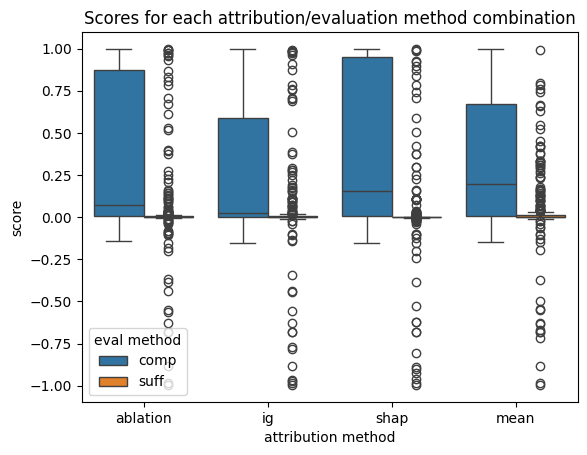

In [330]:
data = combined_for_plotting.unpivot(on=["comp", "suff"], index=["item", "attr method"], variable_name="eval method", value_name="score").rename({"attr method": "attribution method"})
sns.boxplot(data, x="attribution method", y="score", hue="eval method")
plt.title("Scores for each attribution/evaluation method combination")
plt.savefig("2A_overview.png")

 As can be seen in the boxplot above, the big majority of sufficiency scores is close to or roughly zero, but there are a lot of exceptions, interestingly enough in both directions. For comprehensiveness, the lowest values start around zero and the majority also clusters around zero, but the range is much wider (but only toward 1, not -1).

In [188]:
len(combined.filter(pl.col("comp") < 0.05))

450

In [214]:
len(combined.unique(subset="item").filter(pl.col("comp_mean") < 0.005))

70

Half the comprehensiveness values are below 0.05 (definitely bad) and 70/300 sentences have a mean below 0.005.

In [210]:
combined.select(("item", "comp_mean")).unique().sort(by=pl.col("comp_mean")).head(10)

item,comp_mean
i64,f64
133,-0.149594
174,0.000024
211,0.000038
234,0.000065
10,0.000086
296,0.000106
18,0.00017
226,0.000196
146,0.000198


In [211]:
combined.sort(by=pl.col("comp")).drop("suff", "suff_mean").head(10)

item,attr method,comp,comp_mean
i64,str,f64,f64
133,"""shap""",-0.154498,-0.149594
133,"""ig""",-0.151167,-0.149594
133,"""ablation""",-0.143117,-0.149594
268,"""ablation""",-0.039714,0.619664
229,"""ablation""",-0.005125,0.000739
32,"""ig""",-0.002212,0.100839
63,"""ig""",-0.000698,0.644187
248,"""ig""",0.000005,0.060529
226,"""ig""",0.000011,0.000196


In [303]:
dataset['test'][combined.sort(by=pl.col("comp")).head(10).get_column("item").unique().to_list()]["original_text"]

['Like most Bond outings in recent years , some of the stunts are so outlandish that they border on being cartoonlike .',
 'Absorbing and disturbing -- perhaps more disturbing than originally intended -- but a little clarity would have gone a long way .',
 'Must be seen to be believed .',
 'Tadpole is a sophisticated , funny and good-natured treat , slight but a pleasure .',
 'A well-made and often lovely depiction of the mysteries of friendship .',
 'Has it ever been possible to say that Williams has truly inhabited a character ?',
 'The principals in this cast are all fine , but Bishop and Stevenson are standouts .',
 'Roman Coppola may never become the filmmaker his Dad was , but heck -- few filmmakers will .']

In [217]:
dataset['test'][133]

{'input_ids': tensor([    0, 41033,    28,   450,     7,    28,  2047,   479,     2]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'text': ['<s>',
  'Must',
  'Ġbe',
  'Ġseen',
  'Ġto',
  'Ġbe',
  'Ġbelieved',
  'Ġ.',
  '</s>'],
 'label': tensor(1),
 'original_text': 'Must be seen to be believed .'}

In [ ]:
def visualise_comp(test_dataset, example, model, k=0.2, use_target_label=True):
    """
    use_target_label means whether the target label or the predicted label should be used for the evaluation.
    """
    baseline_id = tokenizer.unk_token_id  # Set the baseline to the <unk> toke

    input_ids = test_dataset[example]["input_ids"]
    sen_len = len(input_ids)
    n_remove = max(1, int(round(k * sen_len)))
    baseline_ids = torch.tensor([baseline_id] * sen_len, device=DEVICE)
    target_label = test_dataset[example]["label"]
    predicted_label = predict(test_dataset[example])[0]
    text = test_dataset[example]["text"]
    text_target_label = "positive" if target_label == 1 else "negative"
    text_predicted_label = "positive" if predicted_label == 1 else "negative"

    eval_label = target_label if use_target_label else predicted_label

    orig_probabilities = torch.softmax(model(input_ids.unsqueeze(0)).logits, -1)

    print(f'Original text: "{test_dataset[example]["original_text"]}"')
    print(f'Original probabilities: ({orig_probabilities[0,0]:.4f},{orig_probabilities[0,1]:.4f})')
    print(f"Target label: {text_target_label}")
    print(f"Predicted label: {text_predicted_label}")
    if (target_label != predicted_label) and not use_target_label:
        print("Evaluation uses the predicted label instead of the target label")
    print("\n")

    for attr_name, attributor in zip(("ablation", "shap", "ig"), (ablation_attributor, shap_attributor, ig_attributor)):

        attributions = attributor.attribute(input_ids, baseline_ids, eval_label)

        topk_indices = torch.topk(attributions, n_remove).indices
        mask = torch.ones(sen_len, dtype=torch.bool)
        mask[topk_indices] = False
        reduced_text = np.array(text)[mask]
        input_reduced = input_ids[mask]

        #baseline_reduced = baseline_ids[mask]
        #attributions_reduced = attributor.attribute(input_ids, baseline_ids, eval_label)

        if len(input_reduced) == 0:
            reduced_prob = 0.0
        else:
            reduced_prob = torch.softmax(model(input_reduced.unsqueeze(0)).logits, -1)[0, eval_label].item()
        score = orig_probabilities[0, eval_label].item() - reduced_prob

        print(attr_name)
        print(f"Score: {score:.3f}")
        visualize_attribution(text, attributions)
        #visualize_attribution(reduced_text, attributions_reduced)
        print(f'Reduced text: "{detokenize(reduced_text)}"')
        print("\n\n")

In [348]:
visualise_comp(dataset['test'], 133, model)

Original text: "Must be seen to be believed ."
Original probabilities: (0.1563,0.8437)
Target label: positive
Predicted label: positive


ablation
Score: -0.143


Reduced text: "Must seen to be believed"



shap
Score: -0.154


Reduced text: "Must be to be believed"



ig
Score: -0.151


Reduced text: "Must be to be ."





There are a few sentences with scores below zero, but only example 133 got such terrible scores from all attribution methods. The others got slightly or vastly different scores from the other methods. The attributions for sentence 133 vary widly between attribution methods, which is not entirely surprising, since the sentence is very short and removing any word leaves you with a nonsensical sentence. The quality of the results is also showcased by the fact that both ablation and shap attribute a significant part of the sentiment to the period at the end.

In [289]:
visualise_comp(dataset['test'], 174, model)

Original text: "A smart , sweet and playful romantic comedy ."
Target label: positive
Predicted label: positive


ablation
Score: 0.000


Reduced text: "A , sweet and playful romantic ."



shap
Score: 0.000


Reduced text: "A , sweet and romantic comedy ."



ig
Score: 0.000


Reduced text: "A , sweet and romantic comedy ."





In [361]:
visualise_comp(dataset['test'], 229, model, use_target_label=True)

Original text: "Has it ever been possible to say that Williams has truly inhabited a character ?"
Original probabilities: (0.0075,0.9925)
Target label: negative
Predicted label: positive


ablation
Score: -0.005


Reduced text: "Has it ever been to say Williams has truly inhabited a ?"



shap
Score: 0.005


Reduced text: "Has it ever been possible to Williams has truly inhabited a character"



ig
Score: 0.006


Reduced text: "Has it ever been to say Williams has truly inhabited a character"





In [362]:
visualise_comp(dataset['test'], 32, model)

Original text: "Like most Bond outings in recent years , some of the stunts are so outlandish that they border on being cartoonlike ."
Original probabilities: (0.9858,0.0142)
Target label: negative
Predicted label: negative


ablation
Score: 0.190


Reduced text: "Like most Bond outings in recent years , some of the stunts are so outlandish they border ."



shap
Score: 0.114


Reduced text: "Like most Bond outings in recent years , some of the stunts are outlandish border on being ."



ig
Score: -0.002


Reduced text: "Like most Bond outings in recent years , some of the are they border on being cartoonlike ."





Sentence 174 (chosen because of the low mean) is a perfect example of when a sentence is so stuffed with positive adjectives, that removing some words generally leaves you with a shorter, but still (mostly) sensical and positive sentence. It's not surprising that the scores are all virtually zero.

In [198]:
combined.with_columns((pl.col("comp_mean") - pl.col("comp")).alias("comp_diff")).sort(by="comp_diff", descending=True).head(20)

item,attr method,comp,suff,comp_mean,suff_mean,comp_diff
i64,str,f64,f64,f64,f64,f64
268,"""ablation""",-0.039714,-0.032753,0.619664,0.120449,0.659378
105,"""ig""",0.000584,0.010086,0.658271,0.004604,0.657687
225,"""ig""",0.002191,0.089397,0.655711,0.033634,0.65352
215,"""ablation""",0.016043,-0.009501,0.664515,-0.009533,0.648472
185,"""ablation""",0.02749,-0.000224,0.672856,-0.000241,0.645366
63,"""ig""",-0.000698,0.005256,0.644187,0.009985,0.644886
76,"""ig""",0.000674,0.987706,0.645237,0.421986,0.644563
132,"""ig""",0.024162,-0.000527,0.668297,-0.000561,0.644136
153,"""ig""",0.013558,0.004989,0.654398,0.001411,0.64084


The list above made me realised that there is more deviation between comprehensiveness scores from the different attribution methods than I had anticipated. From this limited analysis, it seems especially Integrated  Gradients and Ablation tend to deviate from the others, while Kernel Shapley values deviate less often.

#### sufficiency

In [306]:
def visualise_suff(test_dataset, example, model, k=0.2):
    baseline_id = tokenizer.unk_token_id  # Set the baseline to the <unk> toke

    input_ids = test_dataset[example]["input_ids"]
    sen_len = len(input_ids)
    n_keep = max(1, int(round(k * sen_len)))
    baseline_ids = torch.tensor([baseline_id] * sen_len, device=DEVICE)
    target_label = test_dataset[example]["label"]
    predicted_label = predict(test_dataset[example])[0]
    text = test_dataset[example]["text"]
    text_target_label = "positive" if target_label == 1 else "negative"
    text_predicted_label = "positive" if predicted_label == 1 else "negative"

    orig_prob = torch.softmax(model(input_ids.unsqueeze(0)).logits, -1)[0, target_label].item()

    print(f'Original text: "{test_dataset[example]["original_text"]}"')
    print(f"Target label: {text_target_label}")
    print(f"Predicted label: {text_predicted_label}")
    print("\n")

    for attr_name, attributor in zip(("ablation", "shap", "ig"), (ablation_attributor, shap_attributor, ig_attributor)):

        attributions = attributor.attribute(input_ids, baseline_ids, target_label)

        topk_indices = torch.topk(attributions, n_keep).indices
        topk_indices_sorted = topk_indices.sort().values  # Maintain original order
        reduced_text = np.array(text)[topk_indices_sorted]
        input_reduced = input_ids[topk_indices_sorted]

        if len(input_reduced) == 0:
            reduced_prob = 0.0
        else:
            reduced_prob = torch.softmax(model(input_reduced.unsqueeze(0)).logits, -1)[0, target_label].item()
        score = orig_prob - reduced_prob

        print(attr_name)
        print(f"Score: {score:.3f}")
        visualize_attribution(text, attributions)
        print(f'Reduced text: "{detokenize(reduced_text)}"')
        print("\n\n")

In [352]:
len(combined.filter(pl.col("suff") > 0.1))

100

In [363]:
combined.filter(pl.col("suff") > 0.3).sort(by=pl.col("suff_mean"), descending=True).head(18)

item,attr method,comp,suff,comp_mean,suff_mean
i64,str,f64,f64,f64,f64
22,"""ablation""",0.992345,0.994121,0.992672,0.990412
22,"""ig""",0.992137,0.993578,0.992672,0.990412
22,"""shap""",0.993533,0.983537,0.992672,0.990412
118,"""ablation""",0.821809,0.531529,0.810729,0.796807
118,"""ig""",0.672075,0.962637,0.810729,0.796807
118,"""shap""",0.938303,0.896256,0.810729,0.796807
216,"""ablation""",0.988904,0.781914,0.988904,0.781914
216,"""ig""",0.988904,0.781914,0.988904,0.781914
216,"""shap""",0.988904,0.781914,0.988904,0.781914


In [309]:
visualise_suff(dataset['test'], 22, model)

Original text: "However , it lacks grandeur and that epic quality often associated with Stevenson 's tale as well as with earlier Disney efforts ."
Target label: negative
Predicted label: negative


ablation
Score: 0.994


Reduced text: "lacks grand and quality associated"



shap
Score: 0.992


Reduced text: "lacks and quality associated as"



ig
Score: 0.994


Reduced text: "lacks quality associated ' efforts"





In [308]:
visualise_suff(dataset['test'], 118, model)

Original text: "If your senses have n't been dulled by slasher films and gorefests , if you 're a connoisseur of psychological horror , this is your ticket ."
Target label: positive
Predicted label: positive


ablation
Score: 0.532


Reduced text: "n'tfests ,isseur ."



shap
Score: 0.192


Reduced text: "'tedasherf , you this ticket"



ig
Score: 0.963


Reduced text: "have dull byisseur is your ticket"





In [311]:
visualise_suff(dataset['test'], 216, model)

Original text: "You might not buy the ideas ."
Target label: negative
Predicted label: negative


ablation
Score: 0.782


Reduced text: "not buy"



shap
Score: 0.892


Reduced text: "not"



ig
Score: 0.782


Reduced text: "not buy"





In [353]:
visualise_suff(dataset['test'], 256, model)

Original text: "Now , if it only had a brain ."
Target label: negative
Predicted label: negative


ablation
Score: 0.708


Reduced text: "only had"



shap
Score: 0.708


Reduced text: "only had"



ig
Score: 0.873


Reduced text: "only"





In [354]:
visualise_suff(dataset['test'], 190, model)

Original text: "Daring , mesmerizing and exceedingly hard to forget ."
Target label: positive
Predicted label: positive


ablation
Score: 0.400


Reduced text: "mesmer hard forget"



shap
Score: 0.020


Reduced text: "aring mesmer forget"



ig
Score: 0.983


Reduced text: "mesmer hard to"





In [364]:
visualise_suff(dataset['test'], 172, model)

Original text: "My goodness , Queen Latifah has a lot to offer and she seemed to have no problem flaunting her natural gifts ."
Target label: positive
Predicted label: positive


ablation
Score: 0.990


Reduced text: "goodness lot offer and no"



shap
Score: 0.997


Reduced text: "goodness offer and to no"



ig
Score: 0.003


Reduced text: "goodness lot offer gifts"





In [ ]:
visualise_suff(dataset['test'], 61, model)

Original text: "If this movie were a book , it would be a page-turner , you ca n't wait to see what happens next ."
Target label: positive
Predicted label: positive


ablation
Score: -0.001


Reduced text: "turn you't wait to see"



shap
Score: -0.000


Reduced text: "it aer ca't wait"



ig
Score: 0.985


Reduced text: ", a page-turn wait"





In [358]:
combined.filter(pl.col("suff_mean") > 0).sort(by=pl.col("suff_mean")).head(15)

item,attr method,comp,suff,comp_mean,suff_mean
i64,str,f64,f64,f64,f64
262,"""ablation""",0.00794,-1.1921e-7,0.023549,0.000002
262,"""ig""",0.043705,0.000007,0.023549,0.000002
262,"""shap""",0.019001,-1.1921e-7,0.023549,0.000002
66,"""ablation""",0.017876,0.000313,0.44301,0.000007
66,"""ig""",0.573741,-0.00016,0.44301,0.000007
66,"""shap""",0.737414,-0.000131,0.44301,0.000007
51,"""ablation""",0.119802,-0.000071,0.125106,0.000009
51,"""ig""",0.034628,0.001016,0.125106,0.000009
51,"""shap""",0.220889,-0.000918,0.125106,0.000009


In [359]:
visualise_suff(dataset['test'], 262, model)

Original text: "Morton is , as usual , brilliant ."
Target label: positive
Predicted label: positive


ablation
Score: -0.000


Reduced text: ", brilliant"



shap
Score: 0.000


Reduced text: "ort brilliant"



ig
Score: 0.000


Reduced text: "usual brilliant"





In [360]:
visualise_suff(dataset['test'], 66, model)

Original text: "This is a startling film that gives you a fascinating , albeit depressing view of Iranian rural life close to the Iraqi border ."
Target label: positive
Predicted label: positive


ablation
Score: 0.000


Reduced text: "startling fascinating of Iranian to"



shap
Score: 0.000


Reduced text: "film you fascinating view"



ig
Score: -0.000


Reduced text: "startling film gives fascinating"



